<a href="https://colab.research.google.com/github/jasonherz41/nba_Jason/blob/main/NBA_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
nba_df = pd.read_csv("https://raw.githubusercontent.com/frontiertechinstitute/datasets/refs/heads/main/NBA%202024_25%20Data/nba_2024_25_player_stats.csv")

In [ ]:
nba_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 456 entries, 0 to 455
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   PLAYER_NAME           456 non-null    object 
 1   TEAM_ABBREVIATION     456 non-null    object 
 2   AGE                   456 non-null    float64
 3   GP                    456 non-null    int64  
 4   MIN                   456 non-null    float64
 5   PTS                   456 non-null    float64
 6   REB                   456 non-null    float64
 7   AST                   456 non-null    float64
 8   STL                   456 non-null    float64
 9   BLK                   456 non-null    float64
 10  TOV                   456 non-null    float64
 11  FG_PCT                456 non-null    float64
 12  FG3_PCT               456 non-null    float64
 13  FT_PCT                456 non-null    float64
 14  PLUS_MINUS            456 non-null    float64
 15  PLAYER_HEIGHT_INCHES  4

In [ ]:
nba_df.isnull().sum() #found missing data

,0
PLAYER_NAME,0
TEAM_ABBREVIATION,0
AGE,0
GP,0
MIN,0
PTS,0
REB,0
AST,0
STL,0
BLK,0


In [ ]:
nba_df.loc[nba_df["PLAYER_WEIGHT"].isnull()]
#found the missing weight data

,PLAYER_NAME,TEAM_ABBREVIATION,AGE,GP,MIN,PTS,REB,AST,STL,BLK,TOV,FG_PCT,FG3_PCT,FT_PCT,PLUS_MINUS,PLAYER_HEIGHT_INCHES,PLAYER_WEIGHT,DRAFT_YEAR,DRAFT_ROUND,DRAFT_NUMBER
208,Jaylen Wells,MEM,21.0,79,25.9,10.4,3.4,1.7,0.6,0.1,0.9,0.425,0.352,0.822,2.4,80,NaN,2024,2,39


In [ ]:
nba_df.loc[nba_df["PLAYER_NAME"] == "Jaylen Wells", "PLAYER_WEIGHT"] = 206.0
nba_df.loc[nba_df["PLAYER_NAME"] == "Jaylen Wells", ["PLAYER_NAME", "PLAYER_WEIGHT"]]
#filled the missing weight data

,PLAYER_NAME,PLAYER_WEIGHT
208,Jaylen Wells,206.0


In [ ]:
nba_df.loc[nba_df["DRAFT_ROUND"].isnull()]
nba_df.loc[nba_df["DRAFT_NUMBER"].isnull()]
#found the missing draft data

,PLAYER_NAME,TEAM_ABBREVIATION,AGE,GP,MIN,PTS,REB,AST,STL,BLK,TOV,FG_PCT,FG3_PCT,FT_PCT,PLUS_MINUS,PLAYER_HEIGHT_INCHES,PLAYER_WEIGHT,DRAFT_YEAR,DRAFT_ROUND,DRAFT_NUMBER
158,Haywood Highsmith,MIA,28.0,74,24.6,6.5,3.4,1.5,0.9,0.5,0.7,0.458,0.382,0.721,0.8,77,220.0,2018,NaN,NaN
404,T.J. McConnell,IND,33.0,79,17.9,9.1,2.4,4.4,1.1,0.3,1.4,0.519,0.306,0.740,-0.7,73,190.0,2015,0,NaN


In [ ]:
nba_df.loc[nba_df["PLAYER_NAME"] == "Haywood Highsmith", "DRAFT_ROUND"] = "Undrafted"
nba_df.loc[nba_df["PLAYER_NAME"] == "Haywood Highsmith", "DRAFT_NUMBER"] = "Undrafted"
nba_df.loc[nba_df["PLAYER_NAME"] == "T.J. McConnell", "DRAFT_ROUND"] = "Undrafted"
nba_df.loc[nba_df["PLAYER_NAME"] == "T.J. McConnell", "DRAFT_NUMBER"] = "Undrafted"

nba_df.loc[nba_df["PLAYER_NAME"].isin(["Haywood Highsmith", "T.J. McConnell"]),["PLAYER_NAME", "DRAFT_ROUND", "DRAFT_NUMBER"]]
#filled the missing draft data

,PLAYER_NAME,DRAFT_ROUND,DRAFT_NUMBER
158,Haywood Highsmith,Undrafted,Undrafted
404,T.J. McConnell,Undrafted,Undrafted


In [ ]:
!pip install matplotlib
import matplotlib.pyplot as plt

!pip install pandas
import pandas as pd

!pip install numpy
import numpy as np

!pip install seaborn
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [ ]:
team_df = pd.DataFrame({"TEAM_ABBREVIATION": ["ATL", "BOS", "BKN", "CHA", "CHI", "CLE", "DAL", "DEN", "DET", "GSW",
        "HOU", "IND", "LAC", "LAL", "MEM", "MIA", "MIL", "MIN", "NOP", "NYK",
        "OKC", "ORL", "PHI", "PHX", "POR", "SAC", "SAS", "TOR", "UTA", "WAS"],
        "WINS": [40, 61, 26, 19, 39, 64, 39, 50, 44, 48, 52, 50, 50, 50, 48, 37, 48, 49, 21, 51, 68, 41, 24, 36, 36, 40, 34, 30, 17, 18],
        "LOSSES": [42, 21, 56, 63, 43, 18, 43, 32, 38, 34, 30, 32, 32, 32, 34, 45, 34, 33, 61, 31, 14, 41, 58, 46, 46, 42, 38, 52, 65, 64],
        "TEAM_POINT_DIFF": [-3.4, 9.1, -5.1, -9.3, -6.2, 9.5, 2.4, 3.8, 1.9, 3.3, 4.0, -1.5, 2.1, -1.5, -1.3, 2.6, 1.8, 5.1, -9.5, 4.1, 12.9, 5.2, -2.1, 1.5, -8.5, 2.3, -1.2, -5.9, -6.7, -12.3]})
#created data set with new information

In [ ]:
team_df["WIN_PCT"] = team_df["WINS"]/82
team_df.head()

,TEAM_ABBREVIATION,WINS,LOSSES,TEAM_POINT_DIFF,WIN_PCT
0,ATL,40,42,-3.4,0.487805
1,BOS,61,21,9.1,0.743902
2,BKN,26,56,-5.1,0.317073
3,CHA,19,63,-9.3,0.231707
4,CHI,39,43,-6.2,0.475610


In [ ]:
nba_df = nba_df.merge(team_df, on = "TEAM_ABBREVIATION", how="left")
nba_df.head()
# merged my two data sets

,PLAYER_NAME,TEAM_ABBREVIATION,AGE,GP,MIN,PTS,REB,AST,STL,BLK,...,PLUS_MINUS,PLAYER_HEIGHT_INCHES,PLAYER_WEIGHT,DRAFT_YEAR,DRAFT_ROUND,DRAFT_NUMBER,WINS,LOSSES,TEAM_POINT_DIFF,WIN_PCT
0,A.J. Lawson,TOR,24.0,26,18.7,9.1,3.3,1.2,0.5,0.2,...,-0.7,78,179.0,Undrafted,Undrafted,Undrafted,30,52,-5.9,0.365854
1,AJ Green,MIL,25.0,73,22.7,7.4,2.4,1.5,0.5,0.1,...,3.1,76,190.0,Undrafted,Undrafted,Undrafted,48,34,1.8,0.585366
2,AJ Johnson,WAS,20.0,29,22.0,7.6,2.0,2.6,0.4,0.1,...,-5.2,77,160.0,2024,1,23,18,64,-12.3,0.219512
3,Aaron Gordon,DEN,29.0,51,28.4,14.7,4.8,3.2,0.5,0.3,...,5.9,80,235.0,2014,1,4,50,32,3.8,0.609756
4,Aaron Holiday,HOU,28.0,62,12.8,5.5,1.3,1.3,0.3,0.2,...,1.4,72,185.0,2018,1,23,52,30,4.0,0.634146


In [ ]:
nba_df["ADJ_PLUS_MINUS"]= nba_df["PLUS_MINUS"] - nba_df["TEAM_POINT_DIFF"]
nba_df.head()
# this is more important plus/minus

,PLAYER_NAME,TEAM_ABBREVIATION,AGE,GP,MIN,PTS,REB,AST,STL,BLK,...,PLAYER_HEIGHT_INCHES,PLAYER_WEIGHT,DRAFT_YEAR,DRAFT_ROUND,DRAFT_NUMBER,WINS,LOSSES,TEAM_POINT_DIFF,WIN_PCT,ADJ_PLUS_MINUS
0,A.J. Lawson,TOR,24.0,26,18.7,9.1,3.3,1.2,0.5,0.2,...,78,179.0,Undrafted,Undrafted,Undrafted,30,52,-5.9,0.365854,5.2
1,AJ Green,MIL,25.0,73,22.7,7.4,2.4,1.5,0.5,0.1,...,76,190.0,Undrafted,Undrafted,Undrafted,48,34,1.8,0.585366,1.3
2,AJ Johnson,WAS,20.0,29,22.0,7.6,2.0,2.6,0.4,0.1,...,77,160.0,2024,1,23,18,64,-12.3,0.219512,7.1
3,Aaron Gordon,DEN,29.0,51,28.4,14.7,4.8,3.2,0.5,0.3,...,80,235.0,2014,1,4,50,32,3.8,0.609756,2.1
4,Aaron Holiday,HOU,28.0,62,12.8,5.5,1.3,1.3,0.3,0.2,...,72,185.0,2018,1,23,52,30,4.0,0.634146,-2.6


In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
X_test = nba_df[["TEAM_POINT_DIFF"]]
Y_test = nba_df[["PLUS_MINUS"]]

team_model = LinearRegression()
team_model.fit(X_test, Y_test)

nba_df["EXPECTED_PLUS_MINUS"]=team_model.predict(X_test)

In [ ]:
nba_df["ADJ_PLUS_MINUS"]=(nba_df["PLUS_MINUS"] - nba_df["EXPECTED_PLUS_MINUS"])

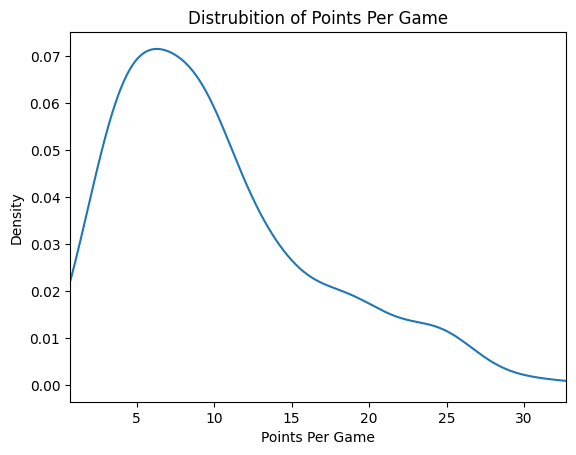

In [ ]:
nba_df["PTS"].plot(kind = "density")

plt.title("Distrubition of Points Per Game")
plt.xlabel("Points Per Game")
plt.xlim(nba_df["PTS"].min(), nba_df["PTS"].max())
plt.show()

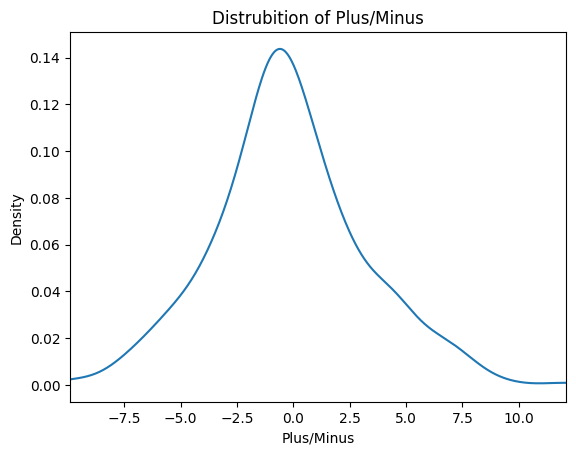

In [ ]:
nba_df["PLUS_MINUS"].plot(kind = "density")

plt.title("Distrubition of Plus/Minus")
plt.xlabel("Plus/Minus")
plt.xlim(nba_df["PLUS_MINUS"].min(), nba_df["PLUS_MINUS"].max())
plt.show()

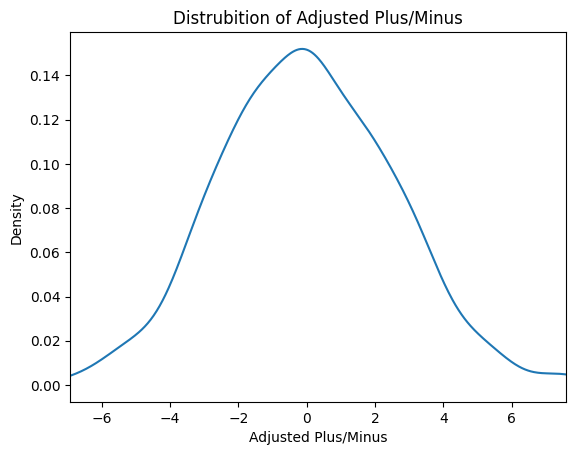

In [ ]:
nba_df["ADJ_PLUS_MINUS"].plot(kind = "density")

plt.title("Distrubition of Adjusted Plus/Minus")
plt.xlabel("Adjusted Plus/Minus")
plt.xlim(nba_df["ADJ_PLUS_MINUS"].min(), nba_df["ADJ_PLUS_MINUS"].max())
plt.show()

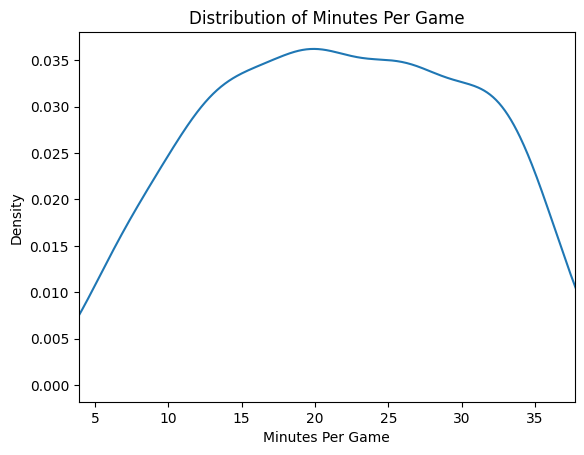

In [ ]:
nba_df["MIN"].plot(kind="density")

plt.title("Distribution of Minutes Per Game")
plt.xlabel("Minutes Per Game")
plt.xlim(nba_df["MIN"].min(), nba_df["MIN"].max())
plt.show()

In [ ]:
nba_df.sort_values("PTS", ascending=False)[["PLAYER_NAME", "TEAM_ABBREVIATION", "PTS", "MIN", "PLUS_MINUS"]].head(10)

,PLAYER_NAME,TEAM_ABBREVIATION,PTS,MIN,PLUS_MINUS
393,Shai Gilgeous-Alexander,OKC,32.7,34.2,12.1
151,Giannis Antetokounmpo,MIL,30.4,34.2,5.0
338,Nikola Jokić,DEN,29.6,36.7,8.5
296,Luka Dončić,LAL,28.2,35.4,6.9
26,Anthony Edwards,MIN,27.6,36.3,3.7
211,Jayson Tatum,BOS,26.8,36.4,7.4
269,Kevin Durant,PHX,26.6,36.5,-0.6
437,Tyrese Maxey,PHI,26.3,37.7,-2.4
59,Cade Cunningham,DET,26.1,35.0,2.5
183,Jalen Brunson,NYK,26.0,35.4,2.2


In [ ]:
nba_df.sort_values("PTS", ascending=True)[["PLAYER_NAME", "TEAM_ABBREVIATION", "PTS", "MIN", "PLUS_MINUS"]].head(10)

,PLAYER_NAME,TEAM_ABBREVIATION,PTS,MIN,PLUS_MINUS
399,Stanley Umude,MIL,0.7,3.9,-0.7
446,Xavier Tillman,BOS,1.0,7.0,-0.4
398,Spencer Jones,DEN,1.3,6.2,-2.3
424,Trey Alexander,DEN,1.3,4.9,-1.0
73,Chris Livingston,MIL,1.4,5.0,-1.4
395,Sidy Cissoko,POR,1.5,5.2,0.4
14,Alex Len,LAL,1.6,8.3,-3.3
237,Jordan Walsh,BOS,1.6,7.8,0.5
447,Yuki Kawamura,MEM,1.6,4.2,1.2
13,Alex Ducas,OKC,1.7,6.0,-1.0


In [ ]:
nba_df.sort_values("PLUS_MINUS", ascending=False)[["PLAYER_NAME", "TEAM_ABBREVIATION", "PTS", "REB", "AST", "PLUS_MINUS"]].head(10)

,PLAYER_NAME,TEAM_ABBREVIATION,PTS,REB,AST,PLUS_MINUS
393,Shai Gilgeous-Alexander,OKC,32.7,5.0,6.4,12.1
71,Chet Holmgren,OKC,15.0,8.0,2.0,9.2
338,Nikola Jokić,DEN,29.6,12.7,10.2,8.5
257,Kawhi Leonard,LAC,21.5,5.9,3.1,8.0
140,Evan Mobley,CLE,18.5,9.3,3.2,7.7
295,Luguentz Dort,OKC,10.1,4.1,1.6,7.7
211,Jayson Tatum,BOS,26.8,8.7,6.0,7.4
126,Donovan Mitchell,CLE,24.0,4.5,5.0,7.4
166,Isaiah Joe,OKC,10.2,2.6,1.6,7.4
165,Isaiah Hartenstein,OKC,11.2,10.7,3.8,7.3


In [ ]:
nba_df.sort_values("PLUS_MINUS", ascending=True)[["PLAYER_NAME", "TEAM_ABBREVIATION", "PTS", "REB", "AST", "PLUS_MINUS"]].head(10)

,PLAYER_NAME,TEAM_ABBREVIATION,PTS,REB,AST,PLUS_MINUS
38,Bilal Coulibaly,WAS,12.3,5.0,3.4,-9.9
56,Bub Carrington,WAS,9.8,4.2,4.4,-9.7
236,Jordan Poole,WAS,20.5,3.0,4.5,-8.2
15,Alex Sarr,WAS,13.0,6.5,2.4,-8.1
253,KJ Simpson,CHA,7.8,3.0,3.1,-7.7
274,Keyonte George,UTA,16.8,3.8,5.6,-7.6
427,Trey Murphy III,NOP,21.2,5.1,3.5,-7.2
333,Nic Claxton,BKN,10.3,7.4,2.2,-7.1
293,Lonnie Walker IV,PHI,12.4,3.2,2.5,-7.1
448,Yves Missi,NOP,9.1,8.2,1.4,-7.0


In [ ]:
nba_df.sort_values("REB", ascending=False)[
    ["PLAYER_NAME", "TEAM_ABBREVIATION", "REB", "PTS", "PLUS_MINUS"]
].head(10)

,PLAYER_NAME,TEAM_ABBREVIATION,REB,PTS,PLUS_MINUS
123,Domantas Sabonis,SAC,13.9,19.1,2.1
255,Karl-Anthony Towns,NYK,12.8,24.4,5.3
338,Nikola Jokić,DEN,12.7,29.6,8.5
169,Ivica Zubac,LAC,12.6,16.8,6.4
443,Walker Kessler,UTA,12.2,11.1,-5.7
151,Giannis Antetokounmpo,MIL,11.9,30.4,5.0
25,Anthony Davis,DAL,11.6,24.7,0.5
440,Victor Wembanyama,SAS,11.0,24.3,2.2
379,Rudy Gobert,MIN,10.9,12.0,4.5
165,Isaiah Hartenstein,OKC,10.7,11.2,7.3


In [ ]:
nba_df.sort_values("AST", ascending=False)[
    ["PLAYER_NAME", "TEAM_ABBREVIATION", "AST", "PTS", "PLUS_MINUS"]
].head(10)

,PLAYER_NAME,TEAM_ABBREVIATION,AST,PTS,PLUS_MINUS
419,Trae Young,ATL,11.6,24.2,0.4
338,Nikola Jokić,DEN,10.2,29.6,8.5
435,Tyrese Haliburton,IND,9.2,18.6,3.0
59,Cade Cunningham,DET,9.1,26.1,2.5
195,James Harden,LAC,8.7,22.8,4.4
291,LeBron James,LAL,8.2,24.4,-0.8
296,Luka Dončić,LAL,7.7,28.2,6.9
74,Chris Paul,SAS,7.4,8.8,0.0
110,Dejounte Murray,NOP,7.4,17.5,-6.7
287,LaMelo Ball,CHA,7.4,25.2,-2.8


In [ ]:
nba_df.sort_values("STL", ascending=False)[
    ["PLAYER_NAME", "TEAM_ABBREVIATION", "STL", "PTS", "PLUS_MINUS"]
].head(10)

,PLAYER_NAME,TEAM_ABBREVIATION,STL,PTS,PLUS_MINUS
136,Dyson Daniels,ATL,3.0,14.1,-0.9
110,Dejounte Murray,NOP,2.0,17.5,-6.7
159,Herbert Jones,NOP,1.9,10.3,-1.0
338,Nikola Jokić,DEN,1.8,29.6,8.5
359,Paul George,PHI,1.8,16.2,-2.0
69,Cason Wallace,OKC,1.8,8.4,5.4
437,Tyrese Maxey,PHI,1.8,26.3,-2.4
296,Luka Dončić,LAL,1.8,28.2,6.9
30,Ausar Thompson,DET,1.7,10.1,1.1
393,Shai Gilgeous-Alexander,OKC,1.7,32.7,12.1


In [ ]:
nba_df.sort_values("ADJ_PLUS_MINUS", ascending=False)[
    ["PLAYER_NAME", "TEAM_ABBREVIATION", "PTS", "REB", "AST", "PLUS_MINUS", "TEAM_POINT_DIFF", "ADJ_PLUS_MINUS"]
].head(10)

,PLAYER_NAME,TEAM_ABBREVIATION,PTS,REB,AST,PLUS_MINUS,TEAM_POINT_DIFF,ADJ_PLUS_MINUS
393,Shai Gilgeous-Alexander,OKC,32.7,5.0,6.4,12.1,12.9,7.594636
296,Luka Dončić,LAL,28.2,8.2,7.7,6.9,-1.5,7.546091
257,Kawhi Leonard,LAC,21.5,5.9,3.1,8.0,2.1,7.358227
338,Nikola Jokić,DEN,29.6,12.7,10.2,8.5,3.8,7.250069
169,Ivica Zubac,LAC,16.8,12.6,2.7,6.4,2.1,5.758227
306,Marcus Smart,WAS,9.0,2.1,3.2,1.2,-12.3,5.709682
275,Khris Middleton,WAS,11.9,3.7,4.1,1.1,-12.3,5.609682
128,Dorian Finney-Smith,LAL,8.7,3.9,1.4,4.9,-1.5,5.546091
68,Caris LeVert,ATL,12.1,3.2,3.4,4.0,-3.4,5.325797
342,Norman Powell,LAC,21.8,3.2,2.1,5.9,2.1,5.258227


In [ ]:
nba_df.sort_values("ADJ_PLUS_MINUS", ascending=True)[
    ["PLAYER_NAME", "TEAM_ABBREVIATION", "PTS", "REB", "AST", "PLUS_MINUS", "TEAM_POINT_DIFF", "ADJ_PLUS_MINUS"]
].head(10)

,PLAYER_NAME,TEAM_ABBREVIATION,PTS,REB,AST,PLUS_MINUS,TEAM_POINT_DIFF,ADJ_PLUS_MINUS
283,Kyle Kuzma,MIL,14.8,5.7,2.3,-6.4,1.8,-6.934451
203,Javonte Green,CLE,5.1,3.2,0.8,-3.1,9.5,-6.389049
293,Lonnie Walker IV,PHI,12.4,3.2,2.5,-7.1,-2.1,-6.239265
45,Bradley Beal,PHX,17.0,3.3,3.7,-5.2,1.5,-5.627129
250,Justin Edwards,PHI,10.1,3.4,1.6,-6.4,-2.1,-5.539265
13,Alex Ducas,OKC,1.7,1.2,0.2,-1.0,12.9,-5.505364
38,Bilal Coulibaly,WAS,12.3,5.0,3.4,-9.9,-12.3,-5.390318
428,Tristan Thompson,CLE,1.7,3.4,0.6,-2.1,9.5,-5.389049
19,Andre Drummond,PHI,7.3,7.8,0.9,-6.1,-2.1,-5.239265
56,Bub Carrington,WAS,9.8,4.2,4.4,-9.7,-12.3,-5.190318


In [ ]:
nba_df["TEAM_ABBREVIATION"].value_counts()

,count
TEAM_ABBREVIATION,
NOP,18
WAS,17
LAL,17
MEM,17
DAL,17
OKC,17
PHX,16
PHI,16
HOU,16


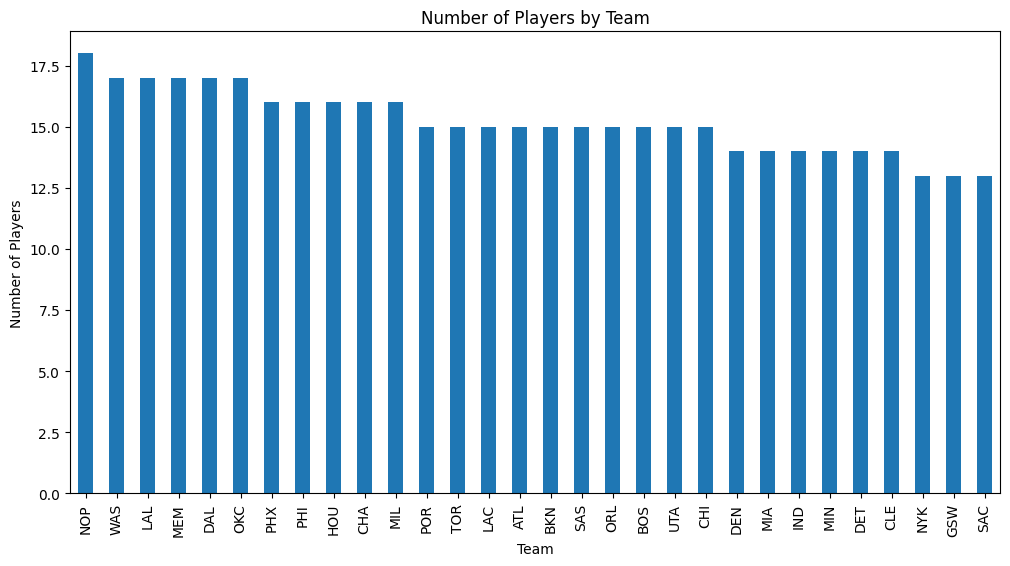

In [ ]:
nba_df["TEAM_ABBREVIATION"].value_counts().plot(kind="bar", figsize=(12, 6))

plt.title("Number of Players by Team")
plt.xlabel("Team")
plt.ylabel("Number of Players")
plt.show()

In [ ]:
number_data=[
    "AGE", "GP", "MIN", "PTS", "REB", "AST", "STL", "BLK",
    "TOV", "FG_PCT", "FG3_PCT", "FT_PCT", "PLUS_MINUS",
    "ADJ_PLUS_MINUS", "PLAYER_HEIGHT_INCHES", "PLAYER_WEIGHT",
    "WINS", "LOSSES", "WIN_PCT", "TEAM_POINT_DIFF"]
correlation_table = nba_df[number_data].corr()

correlation_table

,AGE,GP,MIN,PTS,REB,AST,STL,BLK,TOV,FG_PCT,FG3_PCT,FT_PCT,PLUS_MINUS,ADJ_PLUS_MINUS,PLAYER_HEIGHT_INCHES,PLAYER_WEIGHT,WINS,LOSSES,WIN_PCT,TEAM_POINT_DIFF
AGE,1.000000,0.051452,0.137388,0.107187,0.071276,0.168801,0.104315,-0.007145,0.048766,0.048716,0.094502,0.112317,0.188167,1.309607e-01,-0.075116,0.162298,0.099398,-0.097496,0.099398,1.363710e-01
GP,0.051452,1.000000,0.522017,0.380028,0.316091,0.311540,0.331001,0.139428,0.272041,0.180469,0.135348,0.108736,0.242753,1.898400e-01,0.010476,0.034056,0.160994,-0.168590,0.160994,1.515212e-01
MIN,0.137388,0.522017,1.000000,0.879073,0.622161,0.715873,0.719794,0.341957,0.774734,0.133903,0.192679,0.302965,0.165911,2.536206e-01,0.001165,0.018079,-0.074952,0.075397,-0.074952,-4.120382e-02
PTS,0.107187,0.380028,0.879073,1.000000,0.571518,0.751995,0.615362,0.290388,0.851849,0.144476,0.223765,0.337375,0.231239,3.008498e-01,0.004071,0.026034,-0.026403,0.024284,-0.026403,4.083553e-03
REB,0.071276,0.316091,0.622161,0.571518,1.000000,0.365314,0.387164,0.671298,0.538094,0.505448,-0.225082,-0.088912,0.186328,2.553948e-01,0.542663,0.528286,-0.022503,0.020926,-0.022503,-1.187440e-02
AST,0.168801,0.311540,0.715873,0.751995,0.365314,1.000000,0.647877,0.078879,0.862851,-0.007088,0.164552,0.292613,0.174627,2.484358e-01,-0.267869,-0.165953,-0.028262,0.026222,-0.028262,-2.173775e-02
STL,0.104315,0.331001,0.719794,0.615362,0.387164,0.647877,1.000000,0.214552,0.618567,0.002047,0.204414,0.209332,0.209913,2.774076e-01,-0.192525,-0.160388,-0.013958,0.013788,-0.013958,-1.322036e-03
BLK,-0.007145,0.139428,0.341957,0.290388,0.671298,0.078879,0.214552,1.000000,0.258167,0.466904,-0.260096,-0.144617,0.131600,1.695408e-01,0.576521,0.431225,0.001828,-0.009776,0.001828,4.281189e-03
TOV,0.048766,0.272041,0.774734,0.851849,0.538094,0.862851,0.618567,0.258167,1.000000,0.072257,0.105133,0.216704,0.058088,1.739088e-01,-0.048428,-0.002460,-0.142205,0.140798,-0.142205,-1.138907e-01
FG_PCT,0.048716,0.180469,0.133903,0.144476,0.505448,-0.007088,0.002047,0.466904,0.072257,1.000000,-0.353884,-0.256412,0.192265,1.938261e-01,0.513402,0.496413,0.076485,-0.081500,0.076485,6.920920e-02


In [ ]:
nba_df[number_data].std()

,0
AGE,4.357478
GP,17.588655
MIN,8.638891
PTS,6.490521
REB,2.389930
AST,1.861668
STL,0.390601
BLK,0.412330
TOV,0.820560
FG_PCT,0.075140


In [ ]:
correlation_table["PLUS_MINUS"].sort_values(ascending=False)

,PLUS_MINUS
PLUS_MINUS,1.000000
ADJ_PLUS_MINUS,0.759795
WIN_PCT,0.724161
WINS,0.724161
TEAM_POINT_DIFF,0.650162
GP,0.242753
PTS,0.231239
STL,0.209913
FG_PCT,0.192265
AGE,0.188167


In [ ]:
correlation_table["ADJ_PLUS_MINUS"].sort_values(ascending=False)

,ADJ_PLUS_MINUS
ADJ_PLUS_MINUS,1.000000e+00
PLUS_MINUS,7.597953e-01
PTS,3.008498e-01
STL,2.774076e-01
REB,2.553948e-01
MIN,2.536206e-01
AST,2.484358e-01
WINS,2.190774e-01
WIN_PCT,2.190774e-01
FG_PCT,1.938261e-01


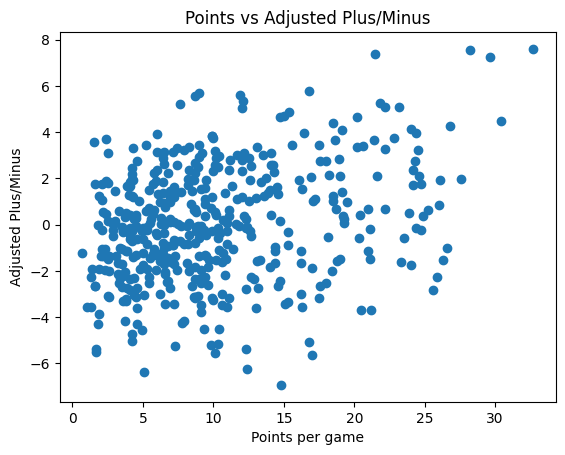

In [ ]:
plt.scatter(nba_df["PTS"], nba_df["ADJ_PLUS_MINUS"])
plt.title("Points vs Adjusted Plus/Minus")
plt.xlabel("Points per game")
plt.ylabel("Adjusted Plus/Minus")
plt.show()

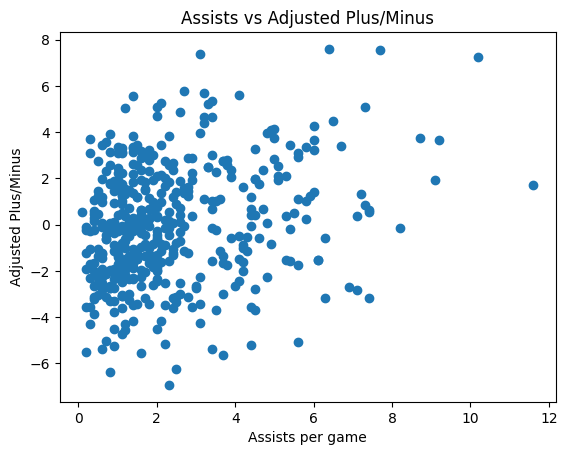

In [ ]:
plt.scatter(nba_df["AST"], nba_df["ADJ_PLUS_MINUS"])
plt.title("Assists vs Adjusted Plus/Minus")
plt.xlabel("Assists per game")
plt.ylabel("Adjusted Plus/Minus")
plt.show()

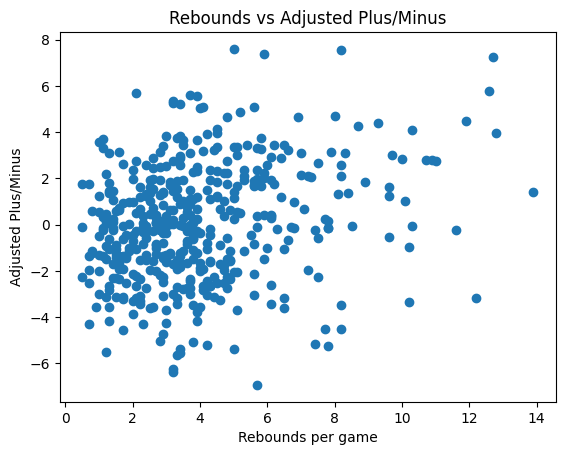

In [ ]:
plt.scatter(nba_df["REB"], nba_df["ADJ_PLUS_MINUS"])
plt.title("Rebounds vs Adjusted Plus/Minus")
plt.xlabel("Rebounds per game")
plt.ylabel("Adjusted Plus/Minus")
plt.show()

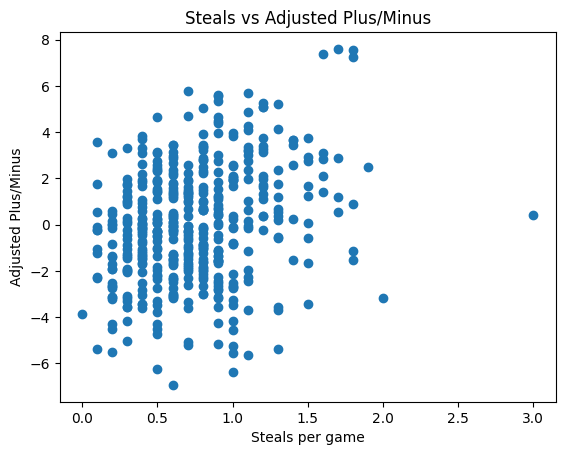

In [ ]:
plt.scatter(nba_df["STL"], nba_df["ADJ_PLUS_MINUS"])
plt.title("Steals vs Adjusted Plus/Minus")
plt.xlabel("Steals per game")
plt.ylabel("Adjusted Plus/Minus")
plt.show()

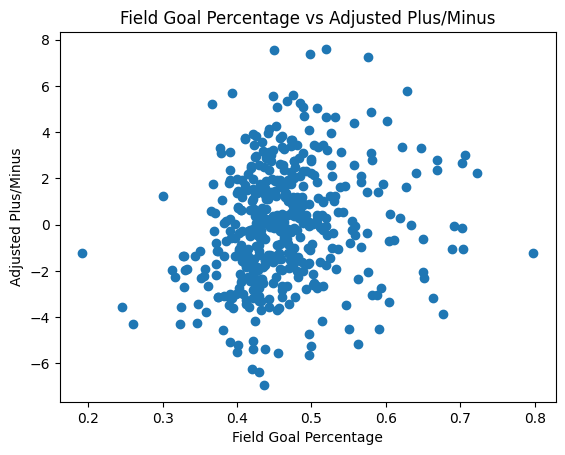

In [ ]:
plt.scatter(nba_df["FG_PCT"], nba_df["ADJ_PLUS_MINUS"])
plt.title("Field Goal Percentage vs Adjusted Plus/Minus")
plt.xlabel("Field Goal Percentage")
plt.ylabel("Adjusted Plus/Minus")
plt.show()

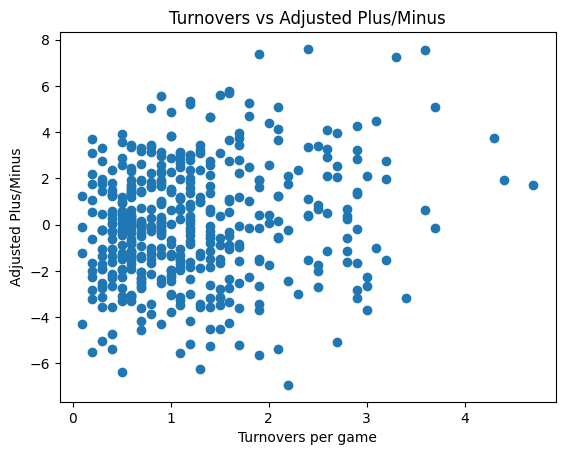

In [ ]:
plt.scatter(nba_df["TOV"], nba_df["ADJ_PLUS_MINUS"])
plt.title("Turnovers vs Adjusted Plus/Minus")
plt.xlabel("Turnovers per game")
plt.ylabel("Adjusted Plus/Minus")
plt.show()

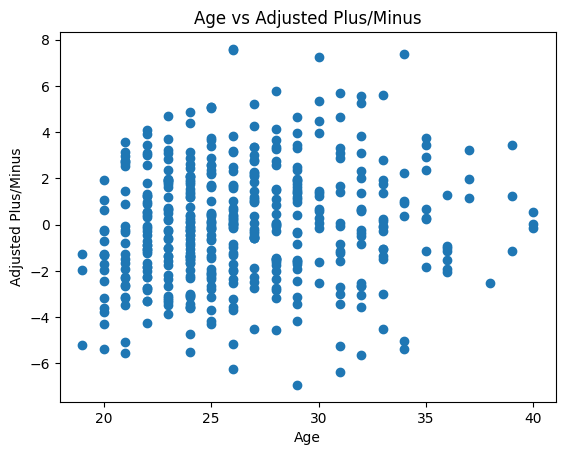

In [ ]:
plt.scatter(nba_df["AGE"], nba_df["ADJ_PLUS_MINUS"])
plt.title("Age vs Adjusted Plus/Minus")
plt.xlabel("Age")
plt.ylabel("Adjusted Plus/Minus")
plt.show()

In [ ]:
nba_df["PTS_SCALED"]= nba_df["PTS"]/nba_df["PTS"].max()
nba_df["REB_SCALED"]= nba_df["REB"]/nba_df["REB"].max()
nba_df["AST_SCALED"]= nba_df["AST"]/nba_df["AST"].max()
nba_df["STL_SCALED"]= nba_df["STL"]/nba_df["STL"].max()
nba_df["BLK_SCALED"]= nba_df["BLK"]/nba_df["BLK"].max()
nba_df["TOV_SCALED"]= nba_df["TOV"]/nba_df["TOV"].max()
nba_df["MIN_SCALED"]= nba_df["MIN"]/nba_df["MIN"].max()
nba_df["FG_PCT_SCALED"]= nba_df["FG_PCT"]/nba_df["FG_PCT"].max()
nba_df["FG3_PCT_SCALED"]= nba_df["FG3_PCT"]/nba_df["FG3_PCT"].max()
nba_df["ADJ_PM_SCALED"]= (nba_df["ADJ_PLUS_MINUS"] - nba_df["ADJ_PLUS_MINUS"].min())/(nba_df["ADJ_PLUS_MINUS"].max()- nba_df["ADJ_PLUS_MINUS"].min())


In [ ]:
nba_df["AGE_VALUE"]= 1 - ((nba_df["AGE"] - nba_df["AGE"].min()) / (nba_df["AGE"].max() - nba_df["AGE"].min()))

In [ ]:
nba_df["TRADE_VALUE_SCORE"]= (0.3*nba_df["ADJ_PM_SCALED"]+
                              0.15*nba_df["PTS_SCALED"] +
                              0.1*nba_df["REB_SCALED"] +
                              0.1*nba_df["AST_SCALED"] +
                              0.1*nba_df["STL_SCALED"] +
                              0.1*nba_df["BLK_SCALED"] +
                              0.1*nba_df["FG_PCT_SCALED"] +
                              0.05*nba_df["FG3_PCT_SCALED"] +
                              0.05*nba_df["MIN_SCALED"] +
                              0.3*nba_df["AGE_VALUE"] -
                              0.08*nba_df["TOV_SCALED"])

In [ ]:
nba_df.sort_values("TRADE_VALUE_SCORE", ascending = False).head(20)

,PLAYER_NAME,TEAM_ABBREVIATION,AGE,GP,MIN,PTS,REB,AST,STL,BLK,...,AST_SCALED,STL_SCALED,BLK_SCALED,TOV_SCALED,MIN_SCALED,FG_PCT_SCALED,FG3_PCT_SCALED,ADJ_PM_SCALED,AGE_VALUE,TRADE_VALUE_SCORE
338,Nikola Jokić,DEN,30.0,70,36.7,29.6,12.7,10.2,1.8,0.6,...,0.879310,0.600000,0.157895,0.702128,0.973475,0.721805,0.738053,0.976284,0.476190,0.928196
393,Shai Gilgeous-Alexander,OKC,26.0,76,34.2,32.7,5.0,6.4,1.7,1.0,...,0.551724,0.566667,0.263158,0.510638,0.907162,0.650376,0.663717,1.000000,0.666667,0.926857
440,Victor Wembanyama,SAS,21.0,46,33.2,24.3,11.0,3.7,1.1,3.8,...,0.318966,0.366667,1.000000,0.680851,0.880637,0.596491,0.623009,0.665783,0.904762,0.910695
296,Luka Dončić,LAL,26.0,50,35.4,28.2,8.2,7.7,1.8,0.4,...,0.663793,0.600000,0.105263,0.765957,0.938992,0.563910,0.651327,0.996659,0.666667,0.898884
16,Alperen Sengun,HOU,22.0,76,31.5,19.1,10.3,4.9,1.1,0.8,...,0.422414,0.366667,0.210526,0.553191,0.835544,0.621554,0.412389,0.757995,0.857143,0.826514
140,Evan Mobley,CLE,24.0,71,30.5,18.5,9.3,3.2,0.9,1.6,...,0.275862,0.300000,0.421053,0.425532,0.809019,0.697995,0.654867,0.780875,0.761905,0.823246
186,Jalen Johnson,ATL,23.0,36,35.7,18.9,10.0,5.0,1.6,1.0,...,0.431034,0.533333,0.263158,0.617021,0.946950,0.626566,0.552212,0.671773,0.809524,0.814034
151,Giannis Antetokounmpo,MIL,30.0,67,34.2,30.4,11.9,6.5,0.9,1.2,...,0.560345,0.300000,0.315789,0.659574,0.907162,0.753133,0.392920,0.784633,0.476190,0.808473
71,Chet Holmgren,OKC,23.0,32,27.4,15.0,8.0,2.0,0.7,2.2,...,0.172414,0.233333,0.578947,0.382979,0.726790,0.614035,0.670796,0.800400,0.809524,0.808453
200,Jaren Jackson Jr.,MEM,25.0,74,29.8,22.2,5.6,2.0,1.2,1.5,...,0.172414,0.400000,0.394737,0.446809,0.790451,0.611529,0.663717,0.826548,0.714286,0.799205


In [ ]:
underdvalued_targets = nba_df[(nba_df["MIN"]<25) &
                              (nba_df["PTS"]<20) &
                              (nba_df["AGE"]<30) &
                              (nba_df["TRADE_VALUE_SCORE"]>0.65)]
underdvalued_targets[["PLAYER_NAME", "TRADE_VALUE_SCORE"]].head(20)

,PLAYER_NAME,TRADE_VALUE_SCORE
5,Aaron Nesmith,0.714106
30,Ausar Thompson,0.682079
103,Day'Ron Sharpe,0.688533
114,Dereck Lively II,0.745892
125,Donovan Clingan,0.734956
174,Jabari Walker,0.653733
260,Kel'el Ware,0.674084
294,Lonzo Ball,0.666423
311,Matas Buzelis,0.677551
326,Mouhamed Gueye,0.687525


**Hypothesis Testing: **

**Question:** Do NBA players with low, medium, and high production all arround have different average adjusted plusminus values?


*   H₀: players with low, medium, and high production have the same adjusted plus/minus
*   Hₐ: at least one group has a different average adjusted plus/minus

In [ ]:
nba_df["PRODUCTION"] = (
    nba_df["PTS_SCALED"] +
    nba_df["REB_SCALED"] +
    nba_df["AST_SCALED"] +
    nba_df["STL_SCALED"] +
    nba_df["BLK_SCALED"] +
    nba_df["FG_PCT_SCALED"] +
    nba_df["FG3_PCT_SCALED"] +
    nba_df["MIN_SCALED"] -
    nba_df["TOV_SCALED"]
) / 9
mean_production = nba_df["PRODUCTION"].mean()
print(mean_production)

0.2916738184929577


In [ ]:
nba_df["PRODUCTION_GROUP"] = "Medium Production"
nba_df.loc[nba_df["PRODUCTION"] < mean_production - nba_df["PRODUCTION"].std(),"PRODUCTION_GROUP"] = "Low Production"
nba_df.loc[nba_df["PRODUCTION"] > mean_production + nba_df["PRODUCTION"].std(),"PRODUCTION_GROUP"] = "High Production"

In [ ]:
nba_df["PRODUCTION_GROUP"].value_counts()

,count
PRODUCTION_GROUP,
Medium Production,309
High Production,80
Low Production,67


In [ ]:
nba_df.groupby("PRODUCTION_GROUP")["ADJ_PLUS_MINUS"].mean()
groups = nba_df.groupby("PRODUCTION_GROUP")["ADJ_PLUS_MINUS"]
low_prod = groups.get_group("Low Production")
med_prod = groups.get_group("Medium Production")
high_prod = groups.get_group("High Production")

In [ ]:
## import required libraries
import numpy as np
import pandas as pd
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [ ]:
f_stat,p_val = stats.f_oneway(low_prod, med_prod, high_prod)
print("F-statistic:", f_stat)
print("p-value:", p_val)

F-statistic: 33.60791137077428
p-value: 2.4584817865445688e-14


In [ ]:
if p_val < 0.05:
    print("Reject the null hypothesis.")
    print("At least one production group has a significantly different average adjusted plus/minus.")
else:
    print("Fail to reject the null hypothesis.")
    print("There is not enough evidence that the production groups have different average adjusted plus/minus values.")

Reject the null hypothesis.
At least one production group has a significantly different average adjusted plus/minus.


In [ ]:
tukey = pairwise_tukeyhsd(endog = nba_df["ADJ_PLUS_MINUS"], groups = nba_df["PRODUCTION_GROUP"])
print(tukey)
print("pairwise p-values:",tukey.pvalues)

          Multiple Comparison of Means - Tukey HSD, FWER=0.05           
     group1           group2      meandiff p-adj   lower   upper  reject
------------------------------------------------------------------------
High Production    Low Production  -2.8481    0.0 -3.7663 -1.9299   True
High Production Medium Production  -2.1827    0.0 -2.8783 -1.4872   True
 Low Production Medium Production   0.6653 0.0922 -0.0819  1.4126  False
------------------------------------------------------------------------
pairwise p-values: [4.06574774e-12 2.28994601e-12 9.22343430e-02]


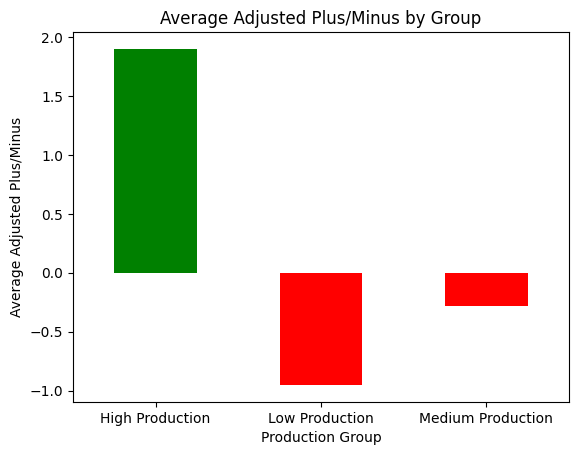

In [ ]:
prod_mean = nba_df.groupby("PRODUCTION_GROUP")["ADJ_PLUS_MINUS"].mean()

colors = ["green" if value > 0 else "red" for value in prod_mean]

prod_mean.plot.bar(color=colors)

plt.title("Average Adjusted Plus/Minus by Group")
plt.xlabel("Production Group")
plt.ylabel("Average Adjusted Plus/Minus")
plt.xticks(rotation=0)
plt.show()